In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os
from sklearn.utils.class_weight import compute_class_weight

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Configuration
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 50
INITIAL_LR = 0.001

In [16]:
def create_improved_cnn_model(num_classes):
    """
    Improved CNN model with better regularization and architecture
    """
    model = models.Sequential([
        # First Convolutional Block
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', 
                     input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                     kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        # Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        # Third Convolutional Block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),
        
        # Fourth Convolutional Block
        layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        
        # Dense Layers
        layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

def create_simple_cnn_model(num_classes):
    """
    Simple but effective CNN model that works without pre-trained weights
    """
    model = models.Sequential([
        # First block
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', 
                     input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Second block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Third block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Fourth block
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        
        # Output
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

In [17]:
def create_data_generators():
    """
    Create data generators with augmentation
    """
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        zoom_range=0.2,
        shear_range=0.1,
        brightness_range=[0.9, 1.1],
        fill_mode='nearest'
    )
    
    val_test_datagen = ImageDataGenerator(rescale=1./255)
    
    train_generator = train_datagen.flow_from_directory(
        '/kaggle/input/combined-unknown-pneumonia-and-tuberculosis/data/train',
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True,
        seed=42
    )
    
    val_generator = val_test_datagen.flow_from_directory(
        '/kaggle/input/combined-unknown-pneumonia-and-tuberculosis/data/val',
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    
    test_generator = val_test_datagen.flow_from_directory(
        '/kaggle/input/combined-unknown-pneumonia-and-tuberculosis/data/test',
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    
    return train_generator, val_generator, test_generator

In [18]:
def create_callbacks():
    """
    Create training callbacks
    """
    return [
        ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1,
            mode='max'
        ),
        EarlyStopping(
            monitor='val_accuracy',
            patience=15,
            restore_best_weights=True,
            verbose=1,
            mode='max'
        ),
        ModelCheckpoint(
            'best_model.h5',
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        )
    ]

def plot_training_history(history):
    """
    Plot training history
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Accuracy plot
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    # Loss plot
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

def evaluate_model(model, test_generator):
    """
    Evaluate the model
    """
    # Predictions
    y_pred = model.predict(test_generator)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = test_generator.classes
    
    # Classification report
    class_names = list(test_generator.class_indices.keys())
    print("Classification Report:")
    print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Calculate accuracy
    test_accuracy = np.sum(y_pred_classes == y_true) / len(y_true)
    print(f"Test Accuracy: {test_accuracy:.4f}")
    
    # Per-class accuracy
    print("\nPer-class Accuracy:")
    for i, class_name in enumerate(class_names):
        class_mask = y_true == i
        if np.sum(class_mask) > 0:
            class_accuracy = np.sum(y_pred_classes[class_mask] == i) / np.sum(class_mask)
            print(f"{class_name}: {class_accuracy:.4f}")

def plot_sample_images(generator):
    """
    Plot sample images from the generator
    """
    class_names = list(generator.class_indices.keys())
    images, labels = next(generator)
    
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    axes = axes.ravel()
    
    for i in range(8):
        axes[i].imshow(images[i])
        axes[i].set_title(f'Class: {class_names[np.argmax(labels[i])]}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

Starting Pneumonia and Tuberculosis Classification Pipeline...
Dataset contains 4 classes: ['UNKNOWN', 'PNEUMONIA', 'TUBERCULOSIS', 'NORMAL']
Loading and preparing data...
Found 13028 images belonging to 4 classes.
Found 761 images belonging to 4 classes.
Found 1527 images belonging to 4 classes.
Detected 4 classes: ['NORMAL', 'PNEUMONIA', 'TUBERCULOSIS', 'UNKNOWN']

Dataset Statistics:
Training samples: 13028
Validation samples: 761
Test samples: 1527
NORMAL: 4667 samples (35.8%)
PNEUMONIA: 3633 samples (27.9%)
TUBERCULOSIS: 3573 samples (27.4%)
UNKNOWN: 1155 samples (8.9%)

Sample images from training set:


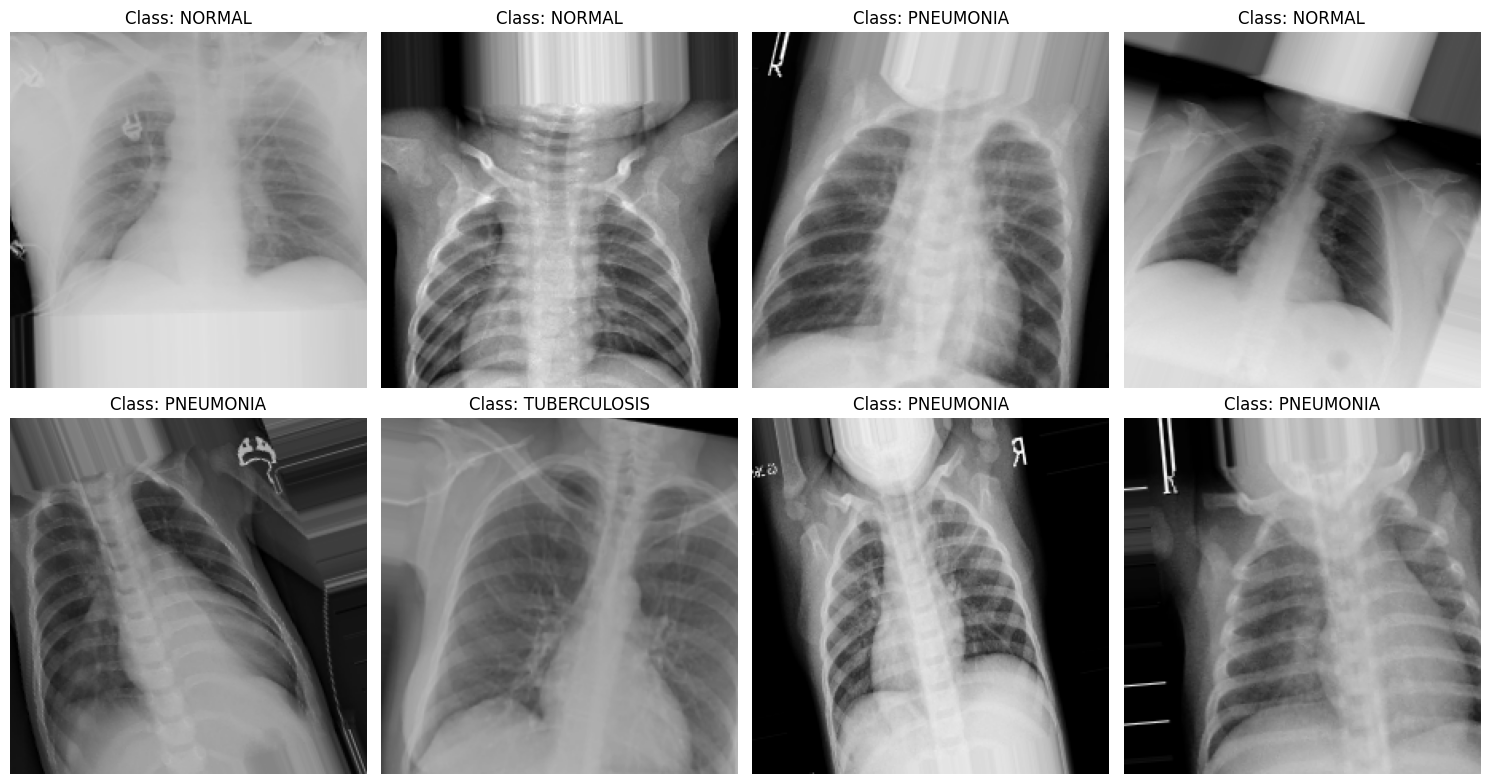

In [19]:
print("Starting Pneumonia and Tuberculosis Classification Pipeline...")

# Check dataset structure
train_path = '/kaggle/input/combined-unknown-pneumonia-and-tuberculosis/data/train'
if os.path.exists(train_path):
    classes = os.listdir(train_path)
    print(f"Dataset contains {len(classes)} classes: {classes}")
    
    print("Loading and preparing data...")
    train_generator, val_generator, test_generator = create_data_generators()
    
    NUM_CLASSES = len(train_generator.class_indices)
    print(f"Detected {NUM_CLASSES} classes: {list(train_generator.class_indices.keys())}")
    
    # Display dataset statistics
    print("\nDataset Statistics:")
    print(f"Training samples: {train_generator.samples}")
    print(f"Validation samples: {val_generator.samples}")
    print(f"Test samples: {test_generator.samples}")
    
    # Calculate class distribution
    class_counts = {}
    for class_name, class_idx in train_generator.class_indices.items():
        count = sum(train_generator.classes == class_idx)
        class_counts[class_name] = count
        print(f"{class_name}: {count} samples ({count/train_generator.samples*100:.1f}%)")
    
    # Plot sample images
    print("\nSample images from training set:")
    plot_sample_images(train_generator)
else:
    print("Dataset not found! Please check the path.")

In [20]:
# Create model (using simple CNN to avoid download issues)
print("Creating model...")
try:
    # Try to create the improved model first
    model = create_improved_cnn_model(NUM_CLASSES)
    print("Using improved CNN model with regularization")
except Exception as e:
    print(f"Error creating improved model: {e}")
    print("Using simple CNN model instead")
    model = create_simple_cnn_model(NUM_CLASSES)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=INITIAL_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Creating model...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Using improved CNN model with regularization


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,276,836 (4.87 MB)

 Trainable params: 1,274,148 (4.86 MB)

 Non-trainable params: 2,688 (10.50 KB)

In [21]:
# Calculate class weights
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: 0.6978787229483608, 1: 0.896504266446463, 2: 0.9115589140778058, 3: 2.8199134199134197}


In [9]:
# Callbacks
callbacks = create_callbacks()

# Train model
print("Starting training...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Starting training...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1758888686.737809     123 service.cc:148] XLA service 0x7c8c90001c20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758888686.739478     123 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1758888686.739504     123 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1758888687.921624     123 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1758888707.807648     123 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5279 - loss: 2.3324
Epoch 1: val_accuracy improved from -inf to 0.14586, saving model to best_model.h5
408/408 ━━━━━━━━━━━━━━━━━━━━ 562s 1s/step - accuracy: 0.5281 - loss: 2.3317 - val_accuracy: 0.1459 - val_loss: 6.2838 - learning_rate: 0.0010
Epoch 2/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 775ms/step - accuracy: 0.7214 - loss: 1.5806
Epoch 2: val_accuracy did not improve from 0.14586
408/408 ━━━━━━━━━━━━━━━━━━━━ 327s 800ms/step - accuracy: 0.7215 - loss: 1.5803 - val_accuracy: 0.0999 - val_loss: 5.6527 - learning_rate: 0.0010
Epoch 3/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 789ms/step - accuracy: 0.7541 - loss: 1.2330
Epoch 3: val_accuracy improved from 0.14586 to 0.43233, saving model to best_model.h5
408/408 ━━━━━━━━━━━━━━━━━━━━ 333s 814ms/step - accuracy: 0.7541 - loss: 1.2328 - val_accuracy: 0.4323 - val_loss: 2.1283 - learning_rate: 0.0010
Epoch 4/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 823ms/step - accuracy: 0.7872 - loss: 0.9985
Epoch 4: v

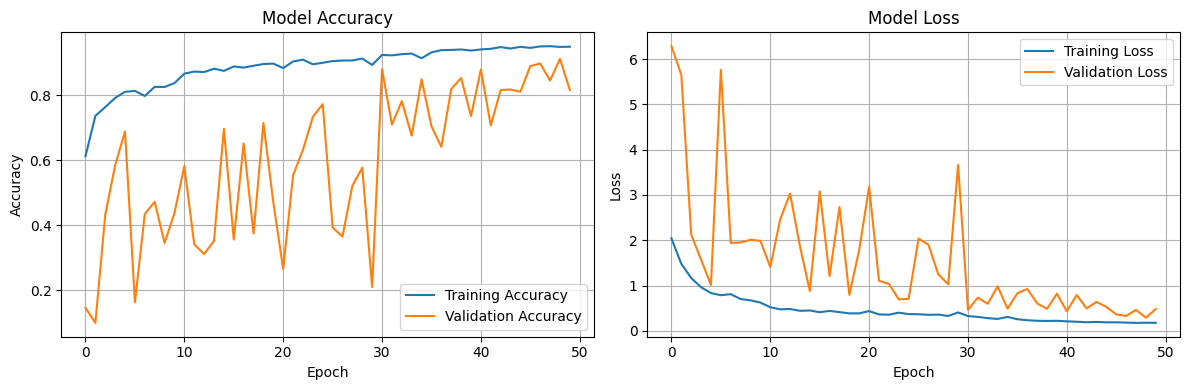

In [15]:
# Plot training history
plot_training_history(history)

Evaluating model...
48/48 ━━━━━━━━━━━━━━━━━━━━ 41s 777ms/step
Classification Report:
              precision    recall  f1-score   support

      NORMAL     0.9312    0.8394    0.8829       548
   PNEUMONIA     0.9566    0.9297    0.9430       427
TUBERCULOSIS     0.8282    0.9592    0.8889       417
     UNKNOWN     1.0000    1.0000    1.0000       135

    accuracy                         0.9116      1527
   macro avg     0.9290    0.9321    0.9287      1527
weighted avg     0.9162    0.9116    0.9117      1527



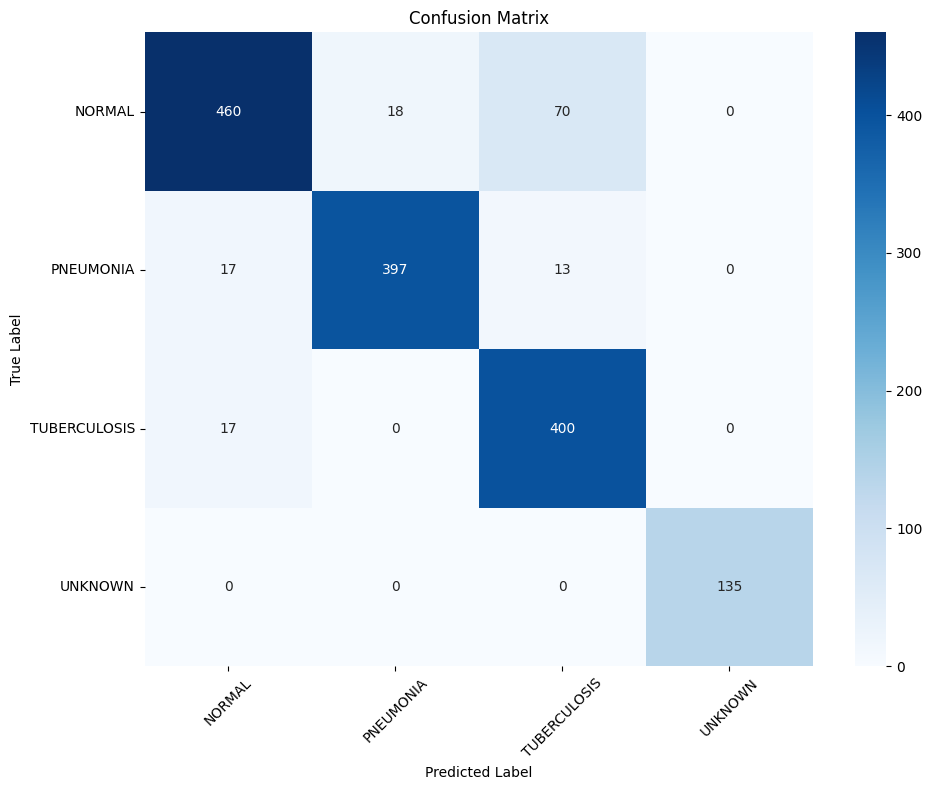

Test Accuracy: 0.9116

Per-class Accuracy:
NORMAL: 0.8394
PNEUMONIA: 0.9297
TUBERCULOSIS: 0.9592
UNKNOWN: 1.0000
Model saved successfully!


In [16]:
# Evaluate model
print("Evaluating model...")
evaluate_model(model, test_generator)

# Save model
model.save('pneumonia_tb_classifier.h5')
print("Model saved successfully!")

# **GradCAM Implementation**

In [22]:
import tensorflow as tf
from tensorflow import keras

# Method 1: Load as SavedModel using tf.keras.models.load_model
try:
    model = tf.keras.models.load_model('/kaggle/input/best_model1.h5/keras/default/1/best_model.h5')
    print("✅ Model loaded successfully as SavedModel!")
    print(f"Model type: {type(model)}")
    model.summary()
except Exception as e:
    print(f"❌ Error loading as SavedModel: {e}")

✅ Model loaded successfully as SavedModel!
Model type: <class 'keras.src.models.sequential.Sequential'>


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,276,838 (4.87 MB)

 Trainable params: 1,274,148 (4.86 MB)

 Non-trainable params: 2,688 (10.50 KB)

 Optimizer params: 2 (12.00 B)

In [43]:
class LayerByLayerGradCAM:
    """
    Even more robust Grad-CAM that manually computes forward pass
    """
    def __init__(self, model):
        self.model = model
        self.layer_outputs = {}
        
        # Build the model
        self._ensure_model_built()
        
        # Find the best layer for Grad-CAM
        self.target_layer = self._find_best_layer()
        print(f" Target layer: {self.target_layer.name}")
    
    def _ensure_model_built(self):
        """Ensure model is built"""
        sample_input = tf.constant(np.ones((1, 224, 224, 3)), dtype=tf.float32)
        _ = self.model(sample_input)
    
    def _find_best_layer(self):
        """Find the best layer for Grad-CAM"""
        # Prefer the last convolutional layer before global pooling
        conv_layers = []
        for layer in self.model.layers:
            if isinstance(layer, tf.keras.layers.Conv2D):
                conv_layers.append(layer)
        
        if conv_layers:
            return conv_layers[-1]
        
        # Fallback to any layer with spatial dimensions
        for layer in reversed(self.model.layers):
            if hasattr(layer, 'output_shape') and len(layer.output_shape) == 4:
                return layer
        
        return self.model.layers[-2]  # Second to last layer
    
    def compute_heatmap(self, image, class_idx=None):
        """Compute heatmap by manually running forward/backward pass"""
        # Convert to tensor if needed
        if isinstance(image, np.ndarray):
            image = tf.constant(image, dtype=tf.float32)
        
        # Track the target layer's output
        target_output = None
        
        with tf.GradientTape() as tape:
            tape.watch(image)
            
            # Manually run forward pass until target layer
            x = image
            for layer in self.model.layers:
                x = layer(x, training=False)
                if layer == self.target_layer:
                    target_output = x
                    tape.watch(target_output)
            
            predictions = x
            
            if class_idx is None:
                class_idx = tf.argmax(predictions[0])
            
            target_score = predictions[:, class_idx]
        
        # Get gradients
        grads = tape.gradient(target_score, target_output)
        
        if grads is None:
            print(" Gradients are None")
            return np.ones((image.shape[1], image.shape[2])) * 0.5, class_idx.numpy()
        
        # Global average pooling for weights
        weights = tf.reduce_mean(grads, axis=(1, 2))
        
        # Weighted combination of feature maps
        heatmap = tf.reduce_sum(target_output * weights[:, tf.newaxis, tf.newaxis, :], axis=-1)
        heatmap = tf.squeeze(heatmap)
        
        # ReLU and normalize
        heatmap = tf.maximum(heatmap, 0)
        if tf.reduce_max(heatmap) > 0:
            heatmap /= tf.reduce_max(heatmap)
        
        return heatmap.numpy(), class_idx.numpy()

# Try the layer-by-layer approach if others fail
if grad_cam is None:
    print("Trying LayerByLayerGradCAM...")
    try:
        grad_cam = LayerByLayerGradCAM(model_rebuilt)
        print("LayerByLayerGradCAM initialized successfully!")
    except Exception as e:
        print(f" LayerByLayerGradCAM failed: {e}")
        grad_cam = None

In [64]:
# Test with real data from the test generator
if grad_cam is not None and 'test_generator' in globals():
    print(" Testing with real data...")
    
    try:
        # Get a batch of test data
        test_images, test_labels = next(test_generator)
        sample_image = test_images[2:3]
        
        print(f"Sample image shape: {sample_image.shape}")
        
        # Compute heatmap
        heatmap, class_idx = grad_cam.compute_heatmap(sample_image)
        
        print(f"Grad-CAM working!")
        print(f"Heatmap shape: {heatmap.shape}")
        print(f"Heatmap range: {heatmap.min():.3f} to {heatmap.max():.3f}")
        
        # Get class names
        class_names = list(test_generator.class_indices.keys())
        if class_idx < len(class_names):
            print(f"Predicted class: {class_names[class_idx]}")
            
    except Exception as e:
        print(f"Test with real data failed: {e}")
else:
    print(" Cannot test - Grad-CAM or test generator not available")

 Testing with real data...
Sample image shape: (1, 224, 224, 3)
Grad-CAM working!
Heatmap shape: (28, 28)
Heatmap range: 0.000 to 1.000
Predicted class: PNEUMONIA


In [65]:
import matplotlib.pyplot as plt
import cv2

def visualize_gradcam(grad_cam, test_generator, num_images=4):
    """Visualize Grad-CAM results"""
    if grad_cam is None:
        print(" Grad-CAM not available")
        return
    
    class_names = list(test_generator.class_indices.keys())
    
    # Get sample images
    images, labels = next(test_generator)
    
    fig, axes = plt.subplots(2, num_images, figsize=(20, 10))
    
    for i in range(min(num_images, len(images))):
        # Get image and true label
        img = images[i]
        true_label_idx = np.argmax(labels[i])
        true_class = class_names[true_label_idx]
        
        # Compute heatmap
        img_expanded = np.expand_dims(img, axis=0)
        heatmap, pred_idx = grad_cam.compute_heatmap(img_expanded)
        pred_class = class_names[pred_idx]
        
        # Get prediction confidence
        prediction = model_rebuilt.predict(img_expanded, verbose=0)
        confidence = prediction[0][pred_idx]
        
        # Convert image for display
        img_display = (img * 255).astype(np.uint8)
        
        # Create heatmap overlay
        heatmap_resized = cv2.resize(heatmap, (img_display.shape[1], img_display.shape[0]))
        heatmap_uint8 = np.uint8(255 * heatmap_resized)
        heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
        
        # Overlay
        overlayed = cv2.addWeighted(img_display, 0.6, heatmap_colored, 0.4, 0)
        
        # Plot
        axes[0, i].imshow(img_display)
        axes[0, i].set_title(f'True: {true_class}', fontsize=12)
        axes[0, i].axis('off')
        
        axes[1, i].imshow(overlayed)
        axes[1, i].set_title(f'Grad-CAM: {pred_class} ({confidence:.3f})', fontsize=12)
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

 Running Grad-CAM analysis...


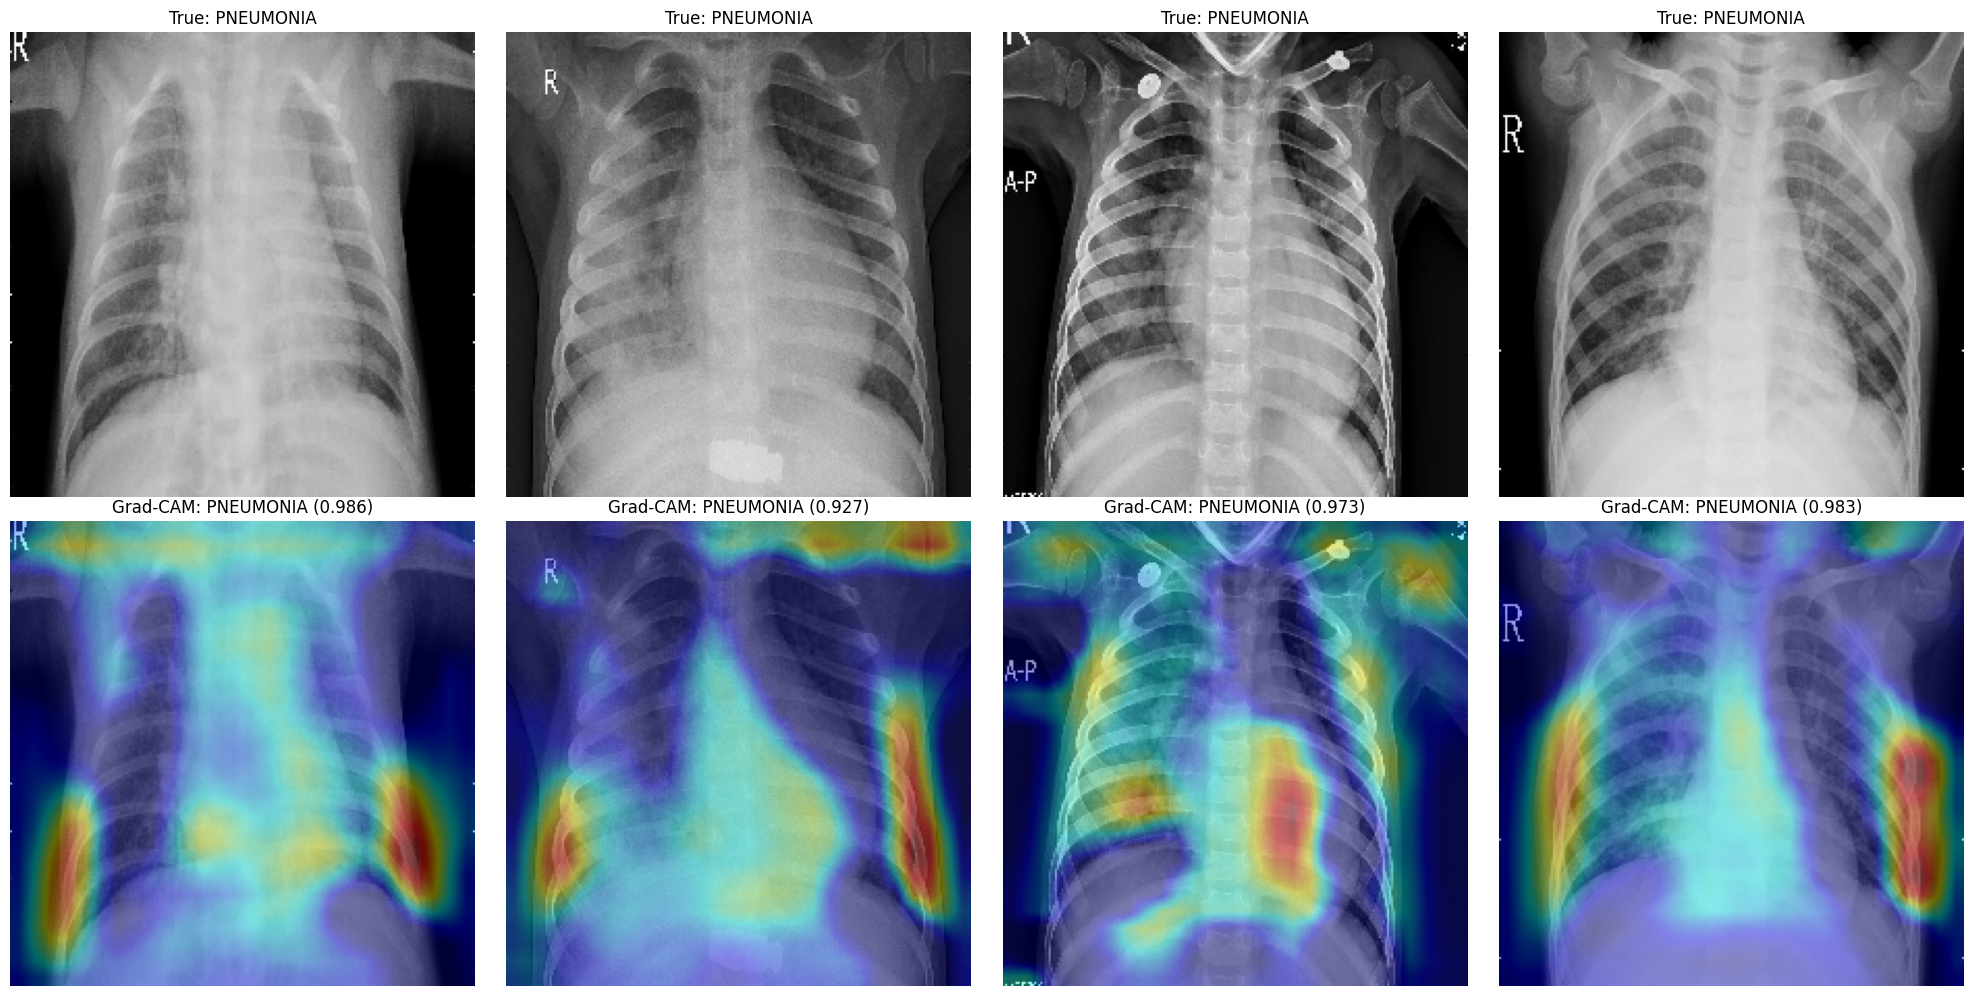

In [67]:
# Final execution
if grad_cam is not None:
    print(" Running Grad-CAM analysis...")
    visualize_gradcam(grad_cam, test_generator, num_images=4)
else:
    print("Grad-CAM initialization failed completely")
    print(" Debugging info:")
    print(f"Model type: {type(model)}")
    print(f"Model built: {model.built}")
    print(f"Model layers: {len(model.layers)}")